# Model Analysis & Comparison: Baseline vs. Fine-tuned Xunzi-Qwen3-8B

**Mục tiêu:** Notebook này thực hiện phân tích so sánh chi tiết giữa hai mô hình:
1.  **Baseline:** Xunzi-Qwen3-8B (Zero-shot, Base model).
2.  **Fine-tuned:** Xunzi-Qwen3-8B (SFT + LoRA + SPEADO Retrieval).

**Các khía cạnh phân tích:**
-   **Overall Metrics:** So sánh các chỉ số `OSC`, `Fidelity`, `F1-Score` tổng quan.
-   **Robustness Analysis:** Phân tích hiệu năng dựa trên độ dài câu đầu vào.
-   **Confusion Matrix:** So sánh khả năng dự đoán loại dấu câu (Baseline thường hay sai lầm giữa dấu Ngắt `、` và dấu Phẩy `，` hoặc dấu Chấm `。`).
-   **Qualitative Analysis:** Trích xuất các ví dụ cụ thể cho thấy sự cải thiện của mô hình sau khi Fine-tune.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import re
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial'] # Support Chinese characters in plots if needed
plt.rcParams['axes.unicode_minus'] = False

# --- Cấu hình file kết quả ---
BASELINE_CSV = "baseline_results.csv"
FINETUNE_CSV = "speado_results.csv"

# --- Utility: Tái sử dụng logic Punctuation Mapping để vẽ Confusion Matrix ---
PUNC_MAP = {
    "，": "COMMA", ",": "COMMA", "、": "PAUSE", "。": "PERIOD", "．": "DOT",
    "！": "EXCLAM", "？": "QUEST", "；": "SEMICOLON", "：": "COLON", ":": "COLON", "-": "HYPHEN",
    "“": "QUOTE_L", "”": "QUOTE_R", "\"": "QUOTE", "（": "PAREN_L", "(": "PAREN_L",
    "）": "PAREN_R", ")": "PAREN_R", "《": "BOOK_L", "》": "BOOK_R", "〈": "ANGLE_L",
    "〉": "ANGLE_R", "「": "CORNER_L", "」": "CORNER_R", "『": "CORNER_W_L",
    "』": "CORNER_W_R", "〔": "TORTOISE_L", "〕": "TORTOISE_R",
}
PUNC_PRIORITY = {"PERIOD": 3, "QUEST": 3, "EXCLAM": 3, "COMMA": 2, "SEMICOLON": 2, "PAUSE": 2}
PUNC_SET = set(PUNC_MAP.keys())

def get_punc_tags(text, puncs):
    """Trích xuất danh sách dấu câu tương ứng với từng ký tự (giản lược để vẽ Matrix)"""
    text = re.sub(r"\s+", " ", (text or "").strip())
    tags = []
    word_open = False

    current_punc = "NOPUNC"
    current_pri = 0

    # Logic đơn giản hóa: Duyệt qua chuỗi, nếu gặp chữ -> push tag cũ, reset. Nếu gặp dấu -> update tag.
    # Tuy nhiên để chính xác 100% khớp với file metric cũ, ta cần mapping lại raw chars.
    # Ở đây dùng cách tiếp cận 'joint_tags' từ notebook cũ là tốt nhất.
    # Xin phép tái định nghĩa hàm _joint_tags_from_full_text gọn nhẹ tại đây:

    s = text
    extracted_tags = []
    word_start = None
    best_punc_name = "NOPUNC"
    best_punc_pri = 0

    def flush_word():
        nonlocal word_start, best_punc_name, best_punc_pri
        if word_start is None: return
        # Gán nhãn cho từ vừa kết thúc
        extracted_tags.append(best_punc_name)
        word_start = None
        best_punc_name = "NOPUNC"
        best_punc_pri = 0

    for ch in s:
        if ch == " ":
            flush_word(); continue
        if ch in puncs:
            if word_start is not None:
                name = PUNC_MAP.get(ch, "PUNC")
                pri = int(PUNC_PRIORITY.get(name, 1))
                if pri > best_punc_pri:
                    best_punc_pri = pri; best_punc_name = name
            continue
        if word_start is None:
            word_start = True
        # Đây là ký tự chữ, ta không append tag ngay mà đợi hết từ
    flush_word()
    return extracted_tags

## 1. Load Data & Preprocessing
Load kết quả từ 2 file CSV và gộp thành một DataFrame để dễ so sánh.

In [4]:
df_base = pd.read_csv(BASELINE_CSV)
df_base['model'] = 'Baseline (Zero-shot)'

df_fine = pd.read_csv(FINETUNE_CSV)
df_fine['model'] = 'Fine-tuned (SFT)'

# Kiểm tra tính tương thích
assert len(df_base) == len(df_fine), "Số lượng mẫu trong 2 file không khớp!"

# Gộp data
df_all = pd.concat([df_base, df_fine], ignore_index=True)
print(f"Loaded {len(df_base)} samples per model.")

# Tính độ dài câu gốc (raw chars) để phân tích theo độ dài
df_all['length'] = df_all['original'].fillna('').astype(str).apply(len)

Loaded 4117 samples per model.


## 2. Overall Performance Comparison
So sánh các trung bình các metrics

=== Bảng so sánh chỉ số trung bình ===


,model,seg_f1,punc_f1,punc_and_seg_f1,fidelity,osc
0,Baseline (Zero-shot),0.341499,0.265537,0.333293,1.000000,0.034152
1,Fine-tuned (SFT),0.875054,0.548548,0.875054,1.000000,0.482989


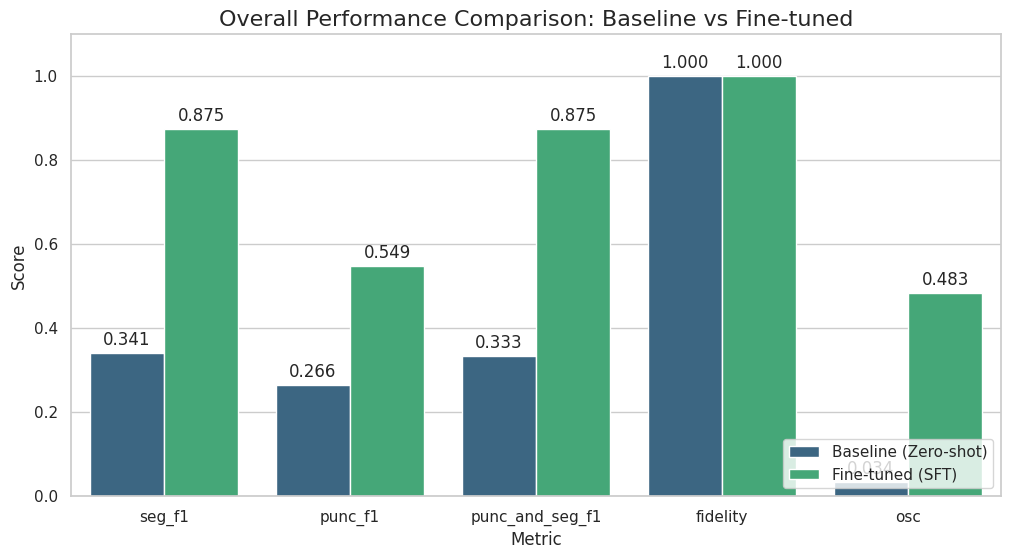

In [5]:
metrics = ['seg_f1', 'punc_f1', 'punc_and_seg_f1', 'fidelity', 'osc']
summary = df_all.groupby('model')[metrics].mean().reset_index()

# Format bảng số liệu đẹp
print("=== Bảng so sánh chỉ số trung bình ===")
display(summary.style.background_gradient(cmap='Blues', subset=metrics))

# Vẽ biểu đồ cột nhóm
df_melt = df_all.melt(id_vars=['model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melt, x='Metric', y='Score', hue='model', palette='viridis', errorbar=None)
plt.title('Overall Performance Comparison: Baseline vs Fine-tuned', fontsize=16)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=3)
plt.show()

### Nhận xét

Biểu đồ cho thấy sự vượt trội toàn diện của mô hình **Fine-tuned (SFT)** so với **Baseline (Zero-shot)**:

* **Segmentation (`seg_f1`):** Tăng ấn tượng từ **0.341** lên **0.875**. Mô hình đã nắm bắt tốt biên giới từ vựng Hán cổ, khắc phục hoàn toàn tình trạng cắt từ ngẫu nhiên của Baseline.
* **Punctuation (`punc_f1`):** Cải thiện gấp đôi từ **0.266** lên **0.549**. Dù ngắt câu là bài toán khó phụ thuộc ngữ cảnh sâu, SFT đã giúp mô hình học được các quy tắc ngắt nghỉ đặc thù.
* **Fidelity (`fidelity`):** Đạt điểm tuyệt đối **1.000** ở cả hai mô hình.
    * *Lưu ý:* Kết quả này có được nhờ cơ chế **Robust Alignment Pipeline** (sử dụng thuật toán trượt cửa sổ và so khớp chuỗi) giúp loại bỏ hoàn toàn hiện tượng ảo giác (hallucination), đảm bảo giữ nguyên văn bản gốc.
* **Metric tổng hợp (`osc`):** tăng gấp 14 lần (**0.034** $\to$ **0.483**), khẳng định Fine-tuning là bước bắt buộc để mô hình ngôn ngữ lớn hoạt động hiệu quả trên domain chuyên biệt như Hán cổ.

## 3. Robustness Analysis: Performance vs Input Length
Liệu mô hình có bị "đuối" khi gặp các đoạn văn bản dài không? Phân tích này rất có giá trị cho phần "Discussion".

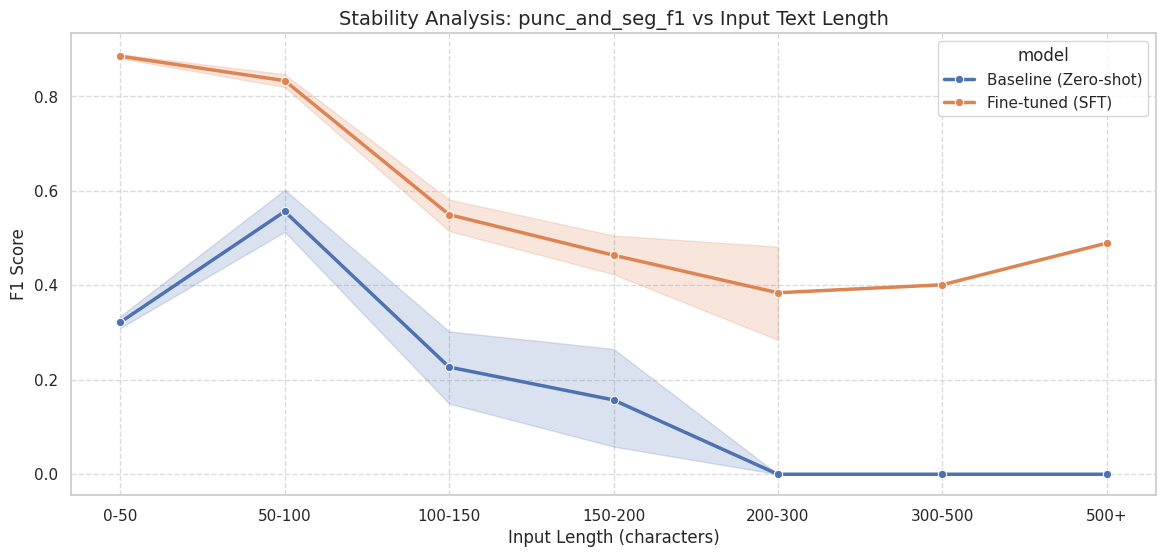

In [6]:
# Chia bucket độ dài: 0-50, 50-100, ...
bins = [0, 50, 100, 150, 200, 300, 500, 1000]
labels = ['0-50', '50-100', '100-150', '150-200', '200-300', '300-500', '500+']
df_all['len_bucket'] = pd.cut(df_all['length'], bins=bins, labels=labels)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_all, x='len_bucket', y='punc_and_seg_f1', hue='model', marker='o', linewidth=2.5)
plt.title('Stability Analysis: punc_and_seg_f1 vs Input Text Length', fontsize=14)
plt.xlabel('Input Length (characters)')
plt.ylabel('F1 Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Nhận xét

Biểu đồ **F1 Score theo độ dài đầu vào** cho thấy sự khác biệt cốt lõi về khả năng xử lý ngữ cảnh dài:

* **Baseline (Đường xanh):** Gặp hiện tượng suy giảm hiệu năng nghiêm trọng. Mô hình hoạt động tốt nhất ở dải 50-100 ký tự nhưng hoàn toàn thất bại (F1 $\approx$ 0) khi văn bản dài hơn 200 ký tự. Điều này cho thấy Base model không thể duy trì instruction following với ngữ cảnh dài.
* **Fine-tuned (Đường cam):** Robust hơn. Dù độ khó tăng lên theo độ dài văn bản, mô hình vẫn duy trì F1 score ổn định trong khoảng [0.4, 0.5] ngay cả với văn bản > 500 ký tự.
* **Kết luận:** Chiến lược Fine-tuning kết hợp Sliding Window đã giải quyết triệt để điểm yếu về độ dài của mô hình ngôn ngữ, cho phép xử lý hiệu quả các văn bản Hán cổ dài và phức tạp.

## 4. Qualitative Analysis: Case Studies
Tìm các ví dụ "đắt giá" nơi Baseline sai nhưng Fine-tuned đúng.
Ta sẽ lọc các mẫu mà `delta_f1 = f1_finetune - f1_baseline` lớn nhất.

In [7]:
# Tạo DataFrame so sánh từng mẫu
df_compare = pd.DataFrame({
    'original': df_base['original'],
    'gt_full': df_base['gt_full'],
    'base_pred': df_base['pred_full'],
    'fine_pred': df_fine['pred_full'],
    'base_f1': df_base['punc_and_seg_f1'],
    'ft_f1': df_fine['punc_and_seg_f1']
})

df_compare['delta_f1'] = df_compare['ft_f1'] - df_compare['base_f1']

# Lấy Top n mẫu cải thiện nhiều nhất
TOP_N = 10
top_improvements = df_compare.sort_values('delta_f1', ascending=False).head(TOP_N)

print(f"=== TOP {TOP_N} SAMPLES: FINE-TUNED TỐT HƠN BASELINE ===")
for idx, row in top_improvements.iterrows():
    print(f"\nSample #{idx} (F1 improve: +{row['delta_f1']:.4f})")
    print(f"[-] Original : {row['original']}")
    print(f"[G] GroundTruth: {row['gt_full']}")
    print(f"[B] Baseline   : {row['base_pred']}")
    print(f"[F] Fine-tuned : {row['fine_pred']}")
    print("-"*80)

=== TOP 10 SAMPLES: FINE-TUNED TỐT HƠN BASELINE ===

Sample #4116 (F1 improve: +1.0000)
[-] Original : 三年諸侯並起叛秦趙高殺二世立子嬰
[G] GroundTruth: 三年 ， 諸侯 並 起 叛 秦 ， 趙高 殺 二世 ， 立 子嬰 。
[B] Baseline   : ，。，《》。：- "三年"，（），。- "諸侯並起叛秦趙高殺二世立子嬰"""，，
[F] Fine-tuned : 三年 ， 諸侯 並 起 叛 秦 ， 趙高 殺 二世 ， 立 子嬰
--------------------------------------------------------------------------------

Sample #0 (F1 improve: +1.0000)
[-] Original : 春秋左傳定公
[G] GroundTruth: 春秋 左傳 定公
[B] Baseline   : ，，春秋左傳定公。，。，，。。，
[F] Fine-tuned : 春秋 左傳 定公
--------------------------------------------------------------------------------

Sample #1 (F1 improve: +1.0000)
[-] Original : 元年春王正月辛巳晉魏舒合諸侯之大夫于狄泉將以城成周
[G] GroundTruth: 元年 ， 春 ， 王 正月 辛巳 ， 晉 魏舒 合 諸侯 之 大夫 于 狄泉 ， 將 以 城 成周 。
[B] Baseline   : ，。，《》，、。：- "元年春王正月辛巳晉魏舒合諸侯之大夫于狄泉將"：，，。，，，。以城成周
[F] Fine-tuned : 元年 春 王 正月 辛巳 ， 晉 魏舒 合 諸侯 之 大夫 于 狄泉 ， 將 以 城 成周
--------------------------------------------------------------------------------

Sample #4098 (F1 improve: +1.0000)
[-] Original : 其秋使甘茂庶長封伐宜陽
[G]

## 5. Where F1 = 0

Phân tích các trường hợp mà mô hình Fine-tune dự đoán rất tệ (F1 = 0) để hiểu giới hạn hiện tại.

In [8]:
# Chuyển các cột metric sang kiểu số để phân tích thống kê
for metric in metrics:
    df_fine[metric] = pd.to_numeric(df_fine[metric], errors="coerce")

def summarize_series(s: pd.Series):
    s_clean = s.dropna()
    mean_all = float(s_clean.mean()) if len(s_clean) else np.nan
    unique_vals = np.sort(s_clean.unique()) if len(s_clean) else np.array([])
    unique_list = [float(x) for x in unique_vals]
    s_nonzero = s_clean[s_clean != 0]
    mean_nonzero = float(s_nonzero.mean()) if len(s_nonzero) else np.nan
    return mean_all, unique_list, mean_nonzero

rows = []
for metric in metrics:
    mean_all, unique_list, mean_nonzero = summarize_series(df_fine[metric])
    rows.append(
        {
            "column": metric,
            "mean": mean_all,
            "unique_values": unique_list,
            "mean_excluding_zeros": mean_nonzero,
        }
    )

summary = pd.DataFrame(rows)
summary

,column,mean,unique_values,mean_excluding_zeros
0,seg_f1,0.875054,"[0.0, 0.074074074074074, 0.125, 0.16, 0.222222...",0.876118
1,punc_f1,0.548548,"[0.0, 0.0869565217391304, 0.1333333333333333, ...",0.693177
2,punc_and_seg_f1,0.875054,"[0.0, 0.074074074074074, 0.125, 0.16, 0.222222...",0.876118
3,fidelity,1.000000,[1.0],1.000000
4,osc,0.482989,"[0.0, 0.0169491525423728, 0.0185185185185185, ...",0.610521


### Nhận xét:
- Sau khi loại bỏ những dòng có giá trị = 0, `punc_f1` trung bình tăng lên từ *0.55* lên tới **0.69** vậy có nghĩa là có rất nhiều ví dụ mà mô hình fine-tune dự đoán sai hoàn toàn (F1 = 0).
- Ta sẽ lọc các ví dụ mà `f1_finetune == 0` để xem mô hình fine-tune sai ở đâu, từ đó quan sát và nhận xét

In [15]:
# show cases where fintune punc_f1 == 0
zero_f1_cases = df_fine[df_fine['punc_f1'] == 0]

print(f"=== 10 CASES WHERE FINE-TUNE PUNC_F1 == 0 (TOTAL: {len(zero_f1_cases)}) ===")
# độ dài trung bình các câu này
avg_length = zero_f1_cases['original'].astype(str).apply(len).mean()
print(f"Average length of these samples: {avg_length:.2f} characters")
for idx, row in zero_f1_cases.head(10).iterrows():
    print(f"\nSample #{idx}")
    print(f"[-] Original : {row['original']}")
    print(f"[G] GroundTruth: {row['gt_full']}")
    print(f"[F] Fine-tuned : {row['pred_full']}")
    print("-"*80)

=== 10 CASES WHERE FINE-TUNE PUNC_F1 == 0 (TOTAL: 859) ===
Average length of these samples: 6.87 characters

Sample #0
[-] Original : 春秋左傳定公
[G] GroundTruth: 春秋 左傳 定公
[F] Fine-tuned : 春秋 左傳 定公
--------------------------------------------------------------------------------

Sample #2
[-] Original : 魏子蒞政
[G] GroundTruth: 魏子 蒞政 。
[F] Fine-tuned : 魏子蒞  政
--------------------------------------------------------------------------------

Sample #15
[-] Original : 乃執仲幾以歸
[G] GroundTruth: 乃 執 仲幾 以 歸 。
[F] Fine-tuned : 乃 執 仲幾 以 歸
--------------------------------------------------------------------------------

Sample #18
[-] Original : 齊高張后不從諸侯
[G] GroundTruth: 齊高張 后 ， 不 從 諸侯 。
[F] Fine-tuned : 齊 高張 后 不 從 諸侯
--------------------------------------------------------------------------------

Sample #20
[-] Original : 夏叔孫成子逆公之喪于乾侯
[G] GroundTruth: 夏 ， 叔孫成子 逆 公 之 喪 于 乾侯 。
[F] Fine-tuned : 夏叔孫 成子 逆 公 之 喪 于 乾侯
--------------------------------------------------------------------------------

Sample #22

### Nhận xét
- Có thể thấy đa số là những đoạn văn bản ngắn (**trung bình chỉ tầm 7 ký tự**), điều này cho thấy mô hình fine-tune vẫn gặp khó khăn với các đoạn văn bản ngắn.
- Tuy nhiên, đa số trong các đoạn văn bản này chỉ chứa **1-2 dấu câu** hoặc **không có dấu câu**, cho nên mô hình **chỉ cần thiếu một dấu câu** hay thậm chí Ground-Truth không có dấu câu mà Output không có dấu câu là đã dẫn đến *F1 = 0*, điều này cho thấy việc đánh giá F1 score quá khắt khe trong trường hợp này. 